8b7bacbf started on gpu 0 New quota is 5258834432
21897d95 started on gpu 0 New quota is 176522240
8b7bacbf finished on gpu 0 New quota is 5264118272
88bcf3b4 started on gpu 0 New quota is 437266432
dd6b8c4b started on gpu 0 New quota is 55105024
dd6b8c4b finished on gpu 0 New quota is 437266432
20270e3b started on gpu 0 New quota is 83650048
21897d95 finished on gpu 0 New quota is 5165962240
e12f9a14 started on gpu 0 New quota is 580005376
4c3d4a41 started on gpu 0 New quota is 14633472
88bcf3b4 finished on gpu 0 New quota is 4841485312
d8e07eb2 started on gpu 0 New quota is 391723008
4c3d4a41 finished on gpu 0 New quota is 957094912
e376de54 started on gpu 0 New quota is 59084800
20270e3b finished on gpu 0 New quota is 412701184
28a6681f started on gpu 0 New quota is 110046208
e12f9a14 finished on gpu 0 New quota is 4696003072
b0039139 started on gpu 0 New quota is 425334272
d8e07eb2 finished on gpu 0 New quota is 4875096576
13e47133 started on gpu 0 New quota is 631950848
e376de54 f

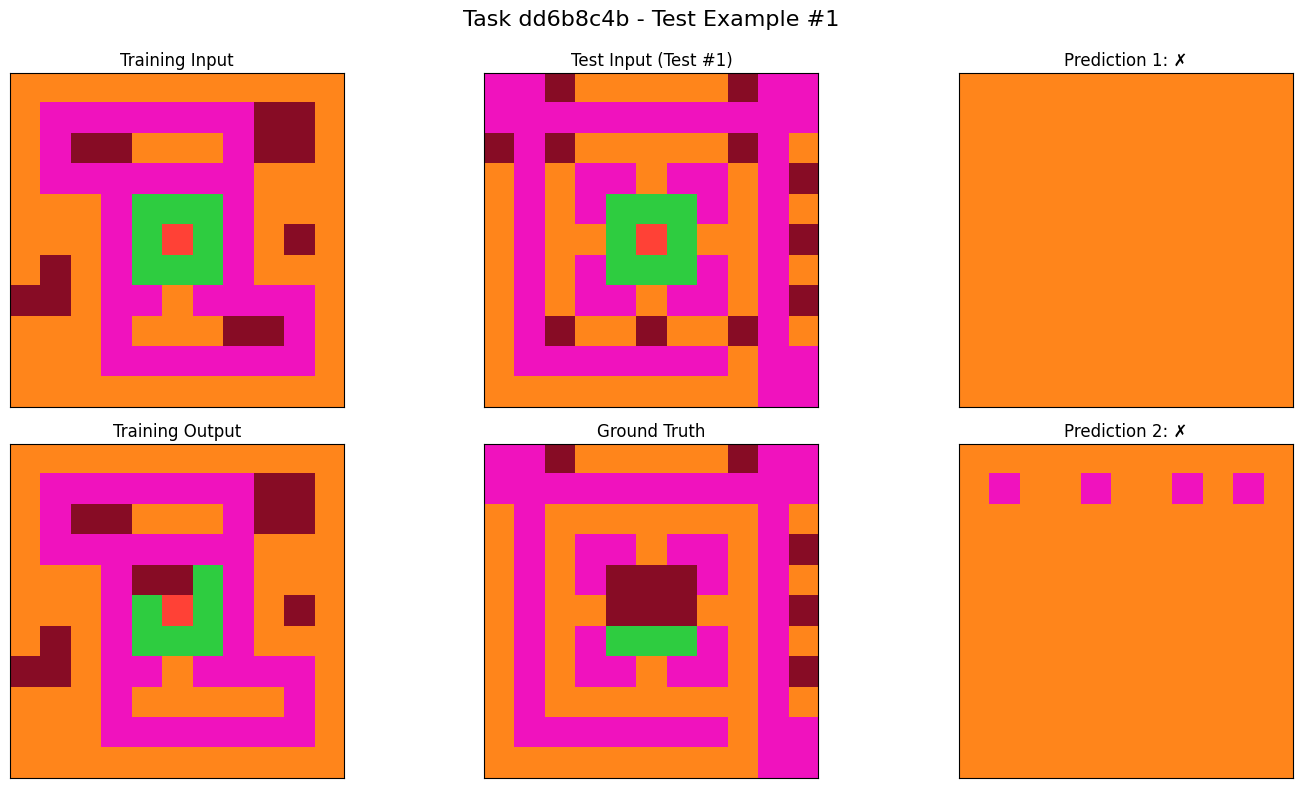


Task: dd6b8c4b - Test #2 (Score: 0/2)
  Results: Attempt 1: ✗, Attempt 2: ✗


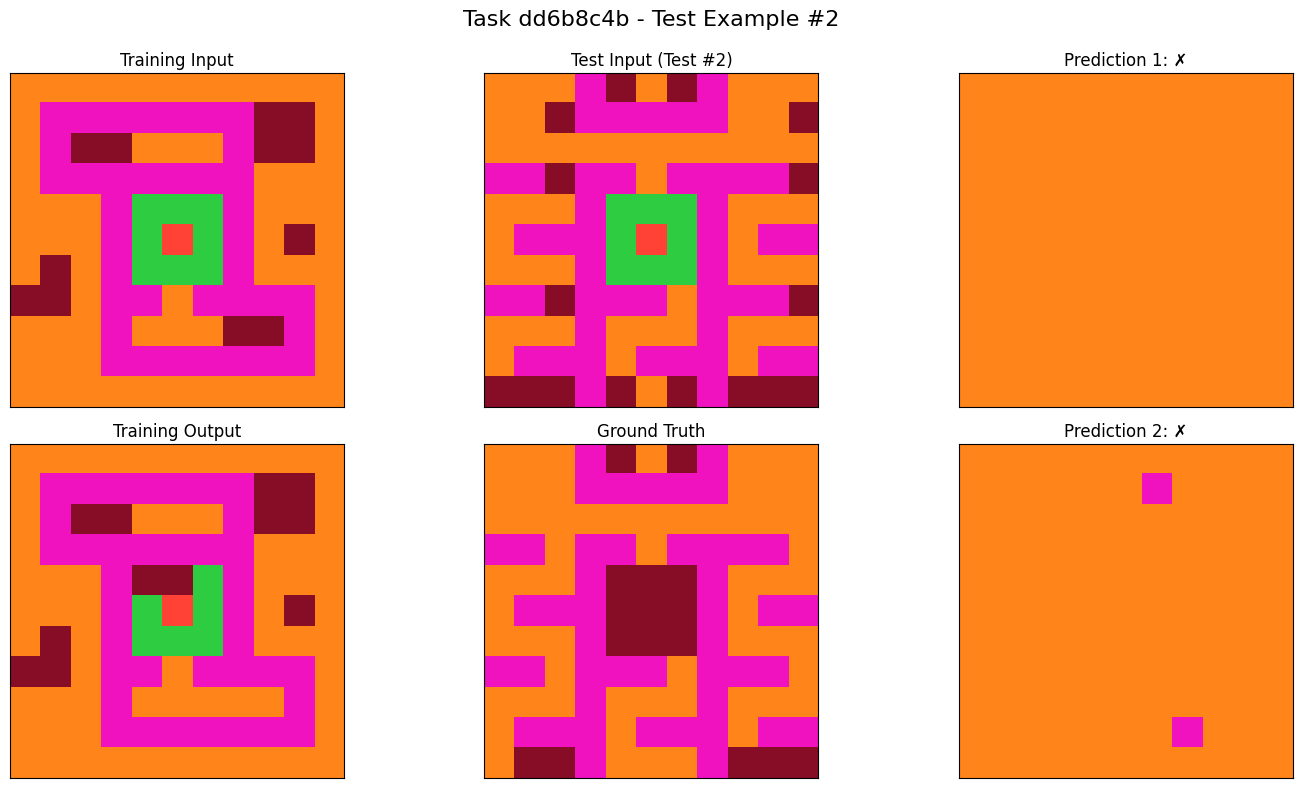


Task: 21897d95 - Test #1 (all zeros - no score)
  Skipping visualization for Task 21897d95 - Test #1 (all predictions are zeros)

Task: 21897d95 - Test #2 (all zeros - no score)
  Skipping visualization for Task 21897d95 - Test #2 (all predictions are zeros)

Task: 88bcf3b4 - Test #1 (Score: 0/2)
  Results: Attempt 1: ✗, Attempt 2: ✗


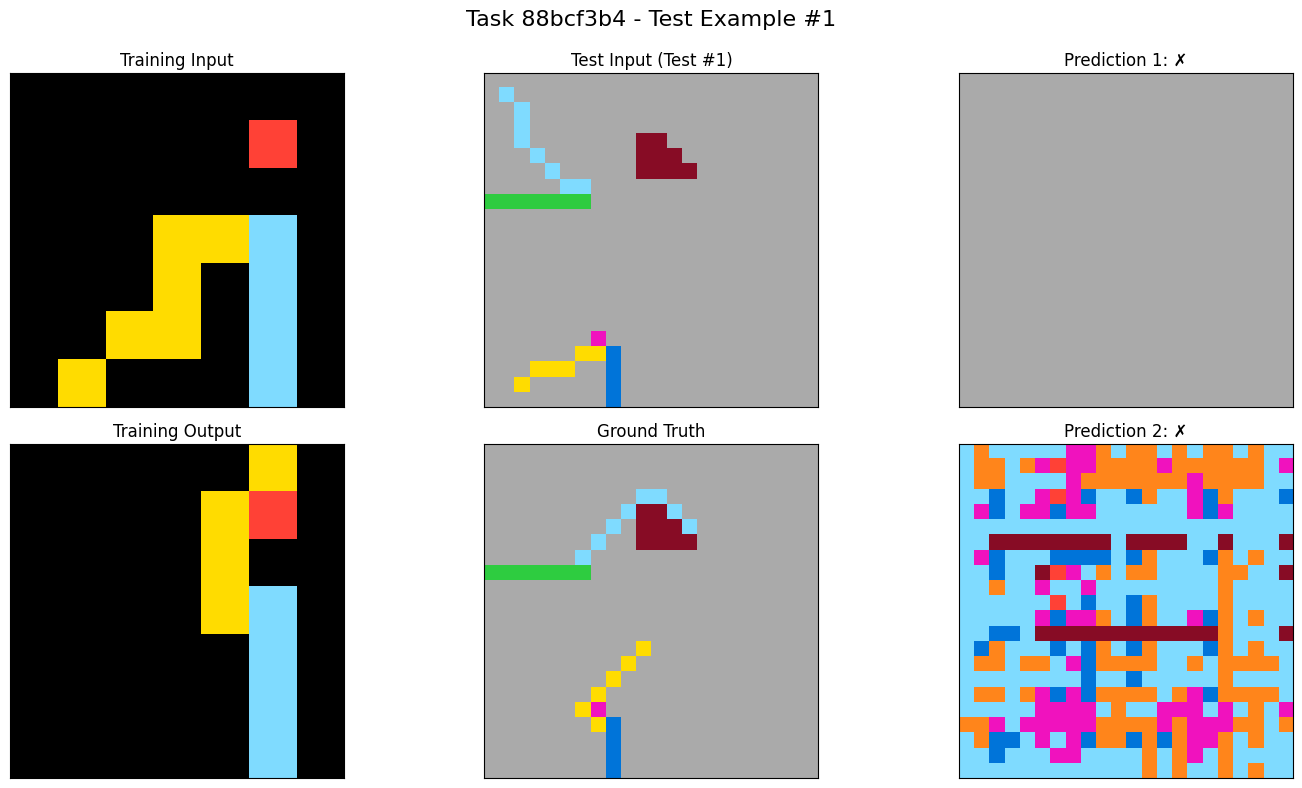


Task: 88bcf3b4 - Test #2 (Score: 0/2)
  Results: Attempt 1: ✗, Attempt 2: ✗


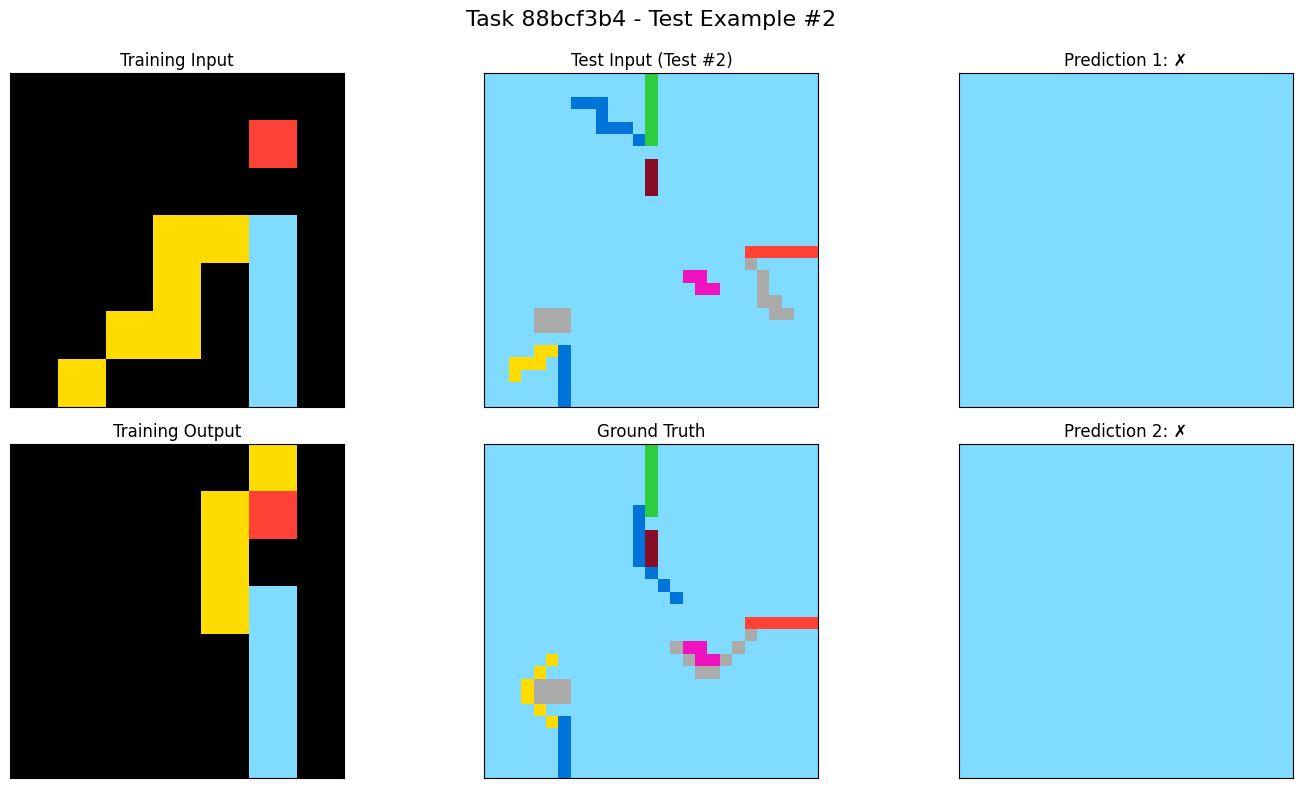


Task: 4c3d4a41 - Test #1 (Score: 0/2)
  Results: Attempt 1: ✗, Attempt 2: ✗


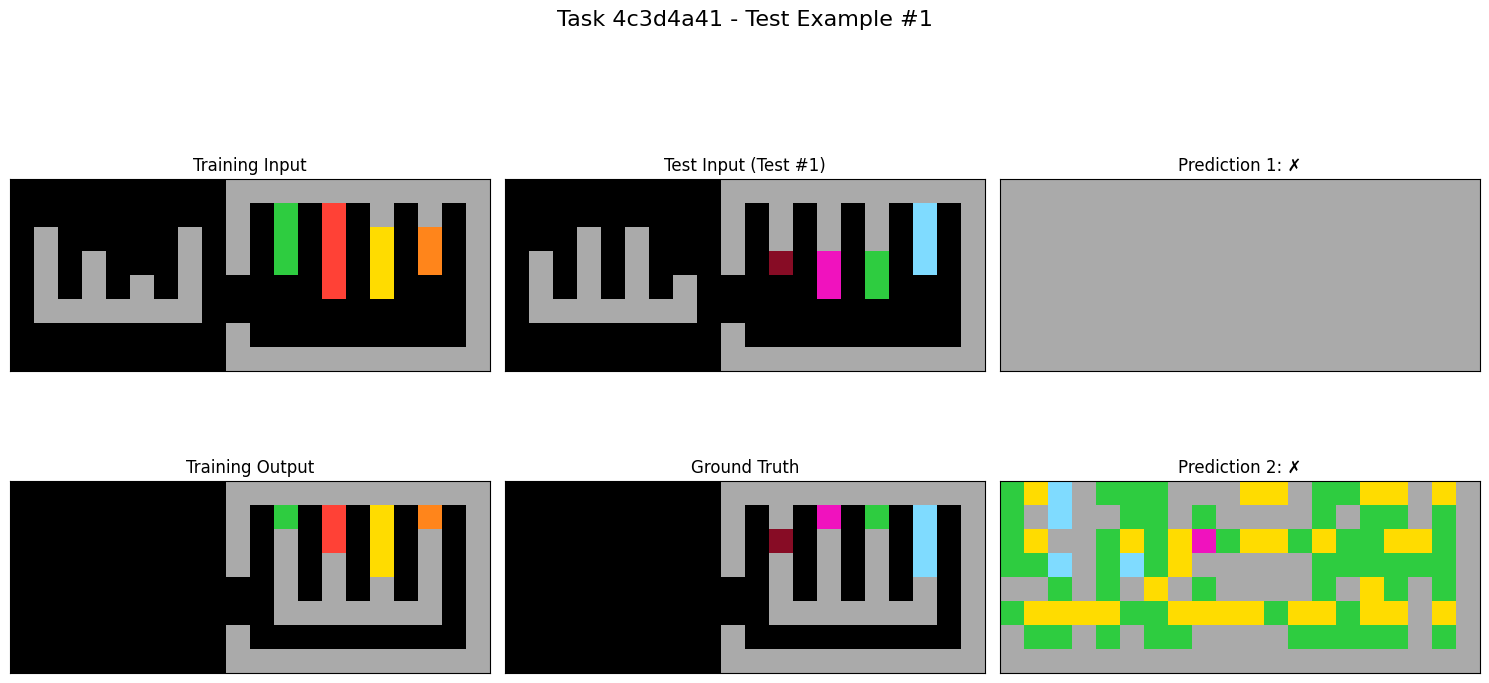


Task: 4c3d4a41 - Test #2 (Score: 0/2)
  Results: Attempt 1: ✗, Attempt 2: ✗


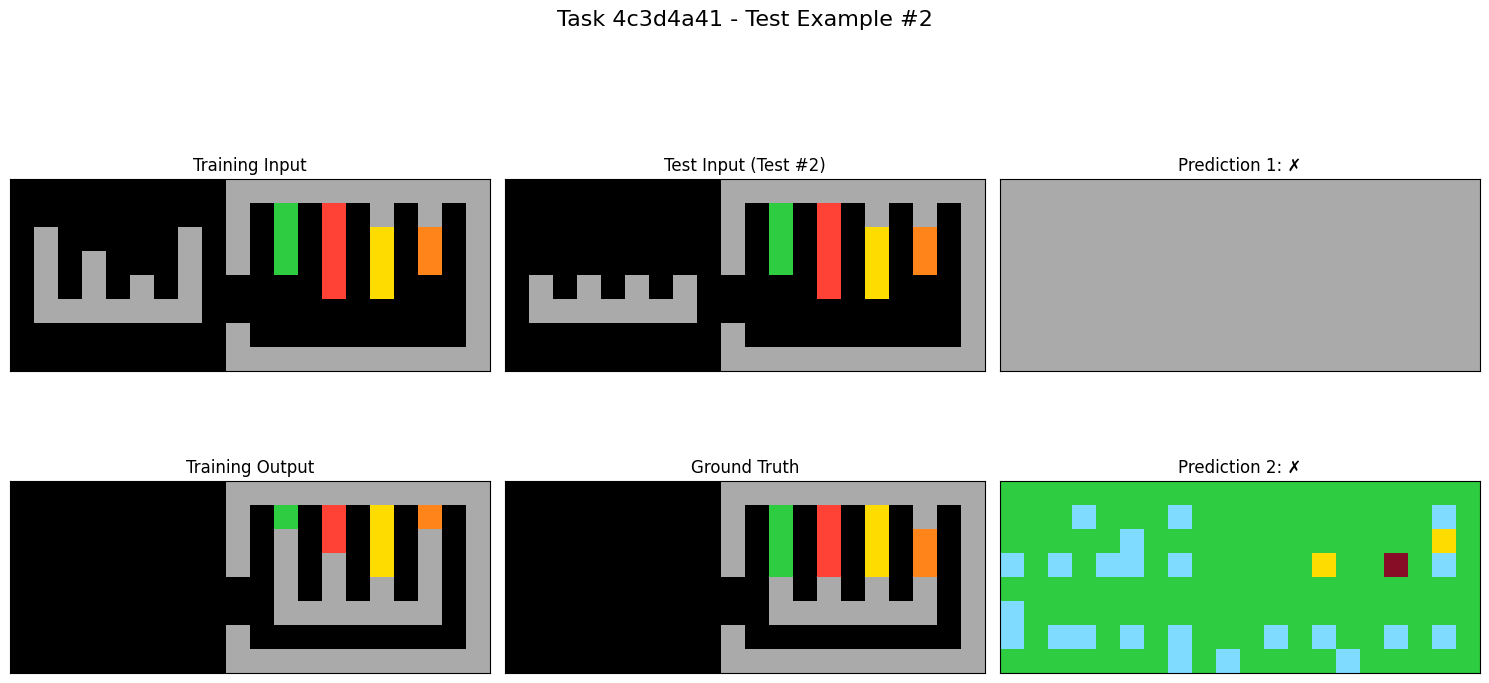


Visualized 6 inference results (skipped 4 with all-zero predictions)


In [1]:
# This notebook is forked from: ARC-AGI Without Pretraining by iliao2345 and edited by 暗黑AGI
# Adapted for ARC Prize 2026 - ARC-AGI-2

import random
import numpy as np
import torch
import os
import sys
import time
import json
import importlib
import multiprocessing
import shutil
from multiprocessing import Pool
import matplotlib.pyplot as plt
from matplotlib import colors

# ==========================================
# GLOBAL SETTINGS & PATHS FOR 2026
# ==========================================
GLOBAL_SEED = 42
fake_mode = not os.getenv('KAGGLE_IS_COMPETITION_RERUN')

# Setting up dynamic path for 2026 competition dataset
DATA_DIR = '/kaggle/input/competitions/arc-prize-2026-arc-agi-2'
if not os.path.exists(DATA_DIR):
    DATA_DIR = '/kaggle/input/arc-prize-2026-arc-agi-2'

def set_all_seeds(seed=GLOBAL_SEED):
    """Set all random seeds to ensure reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

# set_all_seeds()

# ==========================================
# PATCHING EXTERNAL MODULES FOR 2026 PATHS
# ==========================================
# The original code depends on /kaggle/input/darkagicompressarc which has hardcoded 
# paths to 2025. We create a patched copy in /kaggle/working/patched_lib.
PATCHED_DIR = '/kaggle/working/patched_lib'
os.makedirs(PATCHED_DIR, exist_ok=True)

src_dir = '/kaggle/input/darkagicompressarc'
if os.path.exists(src_dir):
    for file_name in os.listdir(src_dir):
        src_file = os.path.join(src_dir, file_name)
        dst_file = os.path.join(PATCHED_DIR, file_name)
        if os.path.isfile(src_file) and file_name.endswith('.py'):
            with open(src_file, 'r') as f:
                content = f.read()
            
            # Replace hardcoded 2025 paths
            content = content.replace('../input/arc-prize-2025', DATA_DIR)
            content = content.replace('/kaggle/input/arc-prize-2025', DATA_DIR)
            
            # Inject a smart `open` wrapper to handle hyphen vs underscore filenames transparently
            override_open = """
import os as _os
_builtin_open = open
def open(file, mode='r', *args, **kwargs):
    if isinstance(file, str) and 'arc-prize' in file:
        if not _os.path.exists(file):
            alt_file = file.replace('_challenges.json', '-challenges.json').replace('_solutions.json', '-solutions.json')
            if _os.path.exists(alt_file):
                file = alt_file
            else:
                alt_file2 = file.replace('-challenges.json', '_challenges.json').replace('-solutions.json', '_solutions.json')
                if _os.path.exists(alt_file2):
                    file = alt_file2
    return _builtin_open(file, mode, *args, **kwargs)
"""
            content = override_open + "\n" + content
            
            with open(dst_file, 'w') as f:
                f.write(content)
        elif os.path.isfile(src_file):
            shutil.copy(src_file, dst_file)

# Prepend the patched directory to sys.path and PYTHONPATH so spawned child processes use it
if PATCHED_DIR not in sys.path:
    sys.path.insert(0, PATCHED_DIR)
os.environ['PYTHONPATH'] = PATCHED_DIR + os.pathsep + os.environ.get('PYTHONPATH', '')

# ==========================================
# MODEL PIPELINE IMPORTS
# ==========================================
# Import preprocessing without name collision
module_path = os.path.join(PATCHED_DIR, "preprocessing.py")
if not os.path.exists(module_path):
    module_path = "/kaggle/input/darkagicompressarc/preprocessing.py" # fallback if patching somehow skipped

module_name = "preprocessing"
spec = importlib.util.spec_from_file_location(module_name, module_path)
preprocessing = importlib.util.module_from_spec(spec)
sys.modules[module_name] = preprocessing
spec.loader.exec_module(preprocessing)

import train
import arc_compressor
import initializers
import multitensor_systems
import layers
import solution_selection
import visualization
import solve_task

# ==========================================
# SCHEDULER & MULTIPROCESSING
# ==========================================
multiprocessing.set_start_method('spawn', force=True)
torch.set_default_dtype(torch.float32)
torch.set_default_device('cuda')
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

def parallelize_runs(gpu_quotas, task_usages, n_iterations, n_tasks, task_names, split, end_time, verbose=False):
    n_cpus = multiprocessing.cpu_count()
    n_gpus = torch.cuda.device_count()
    gpu_quotas = gpu_quotas[:]
    
    t = time.time()
    tasks_started = [False for i in range(n_tasks)]
    tasks_finished = [False for i in range(n_tasks)]
    processes = [None for i in range(n_tasks)]
    process_gpu_ids = [None for i in range(n_tasks)]
    
    with multiprocessing.Manager() as manager:
        memory_dict = manager.dict()
        solutions_dict = manager.dict()
        error_queue = manager.Queue()
        
        while not all(tasks_finished):
            if not error_queue.empty():
                raise ValueError(error_queue.get())
                
            for i in range(n_tasks):
                if tasks_started[i] and not tasks_finished[i]:
                    processes[i].join(timeout=0)
                    if not processes[i].is_alive():
                        tasks_finished[i] = True
                        gpu_quotas[process_gpu_ids[i]] += task_usages[i]
                        if verbose:
                            print(task_names[i], 'finished on gpu', process_gpu_ids[i],
                                  'New quota is', gpu_quotas[process_gpu_ids[i]])
                                  
            for gpu_id in range(n_gpus):
                for i in range(n_tasks):
                    enough_quota = gpu_quotas[gpu_id] > task_usages[i]
                    enough_cpus = sum(map(int, tasks_started)) - sum(map(int, tasks_finished)) < n_cpus
                    if not tasks_started[i] and enough_quota and enough_cpus:
                        gpu_quotas[gpu_id] -= task_usages[i]
                        args = (task_names[i], split, end_time, n_iterations, gpu_id, memory_dict, solutions_dict, error_queue)
                        p = multiprocessing.Process(target=solve_task.solve_task, args=args)
                        p.start()
                        processes[i] = p
                        tasks_started[i] = True
                        process_gpu_ids[i] = gpu_id
                        if verbose:
                            print(task_names[i], 'started on gpu', process_gpu_ids[i],
                                  'New quota is', gpu_quotas[process_gpu_ids[i]])
            time.sleep(1)
            
        if not error_queue.empty():
            raise ValueError(error_queue.get())
        memory_dict = dict(memory_dict)
        solutions_dict = dict(solutions_dict)
        
    time_taken = time.time() - t
    if verbose:
        print('All jobs finished in', time_taken, 'seconds.')
    return memory_dict, solutions_dict, time_taken

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == '__main__':
    start_time = time.time()
    # 12 hour budget
    end_time = start_time + 12*3600 - 1200

    n_cpus = multiprocessing.cpu_count()
    n_gpus = torch.cuda.device_count()

    # Find all the puzzle names robustly (handling hyphen/underscore host typos)
    split = "evaluation" if fake_mode else "test"
    challenges_path = os.path.join(DATA_DIR, f'arc-agi_{split}_challenges.json')
    if not os.path.exists(challenges_path):
         challenges_path = os.path.join(DATA_DIR, f'arc-agi_{split}-challenges.json')
            
    with open(challenges_path, 'r') as f:
        problems = json.load(f)
        
    task_names = list(problems.keys())
    n_tasks = len(task_names)
    del problems

    # Measuring the amount of memory used for every task
    gpu_memory_quotas = [torch.cuda.mem_get_info(i)[0] for i in range(n_gpus)]
    gpu_task_quotas = [int(gpu_memory_quota // (4 * 1024**3)) for gpu_memory_quota in gpu_memory_quotas]
    task_usages = [1 for i in range(n_tasks)]
    memory_dict, _, _ = parallelize_runs(gpu_task_quotas, task_usages, 2, n_tasks, task_names, split, end_time, verbose=False)
    
    # Sort the tasks by decreasing memory usage
    tasks = sorted(memory_dict.items(), key=lambda x: x[1], reverse=True)
    task_names_sorted, task_memory_usages = zip(*tasks)

    # Computing the time taken, while saturating memory
    test_steps = 5 if fake_mode else 20
    safe_gpu_memory_quotas = [memory_quota - 6 * 1024**3 for memory_quota in gpu_memory_quotas]
    _, _, time_taken = parallelize_runs(safe_gpu_memory_quotas, task_memory_usages, test_steps, n_tasks, task_names_sorted, split, end_time, verbose=False)

    # Computing the solution for every task, while saturating memory and time
    time_per_step = time_taken / test_steps
    time_left = end_time - time.time()
    n_steps = 5 if fake_mode else 500 # Adjust dynamically: int(time_left // time_per_step)
    _, solutions_dict, time_taken = parallelize_runs(safe_gpu_memory_quotas, task_memory_usages, n_steps, n_tasks, task_names_sorted, split, end_time, verbose=True)
    
    # Format the solutions and put into submission file
    with open('submission.json', 'w') as f:
        json.dump(solutions_dict, f, indent=4)
        
    print(n_tasks, 'tasks solved.')
    print(n_steps, 'steps taken.')
    print(time_taken, 'seconds taken.')

# ==========================================
# VISUALIZATION UTILITIES
# ==========================================
def get_file_path(base_dir, file_name_options):
    """Helper to return the first file path that exists from a list of options."""
    for opt in file_name_options:
        path = os.path.join(base_dir, opt)
        if os.path.exists(path):
            return path
    return None

def visualize_arc_results():
    """Visualize ARC problem solutions from submission.json"""
    print("\n" + "="*80)
    print("VISUALIZING ARC SOLUTION RESULTS")
    print("="*80)
    
    submission_path = 'submission.json'
    if not os.path.exists(submission_path):
        print(f"Submission file not found at {submission_path}")
        return
    
    # Load submission data
    with open(submission_path, 'r') as f:
        submission_data = json.load(f)
    print(f"Loaded submission with {len(submission_data)} tasks")

    # Safely load 2026 ground truths / evaluations
    train_sol_path = get_file_path(DATA_DIR, ['arc-agi_training_solutions.json', 'arc-agi_training-solutions.json'])
    eval_sol_path = get_file_path(DATA_DIR, ['arc-agi_evaluation_solutions.json', 'arc-agi_evaluation-solutions.json'])
    challenge_path = get_file_path(DATA_DIR, [f'arc-agi_{"evaluation" if fake_mode else "test"}_challenges.json',
                                              f'arc-agi_{"evaluation" if fake_mode else "test"}-challenges.json'])
    
    training_solution = {}
    if train_sol_path:
        with open(train_sol_path, 'r') as f:
            training_solution = json.load(f)
            
    evaluation_solution = {}
    if eval_sol_path:
        with open(eval_sol_path, 'r') as f:
            evaluation_solution = json.load(f)
            
    arc_data = {}
    if challenge_path:
        with open(challenge_path, 'r') as f:
            arc_data = json.load(f)
            
    conbiled_solution = {}
    for case_id in arc_data:
        if case_id in training_solution:
            conbiled_solution[case_id] = training_solution[case_id][0]
        elif case_id in evaluation_solution:
            conbiled_solution[case_id] = evaluation_solution[case_id][0]
            
    # ARC color map - colors for values 0-9
    cmap = colors.ListedColormap(
        ['#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00',
         '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#870C25'])
    norm = colors.Normalize(vmin=0, vmax=9)
    
    def is_non_trivial_prediction(pred_array):
        return np.any(np.array(pred_array) > 0)
    
    def visualize_submission_result(task_id, task_data, submission_output, test_idx):
        pred_1 = np.array(submission_output['attempt_1'])
        pred_2 = np.array(submission_output['attempt_2'])
        
        if not is_non_trivial_prediction(pred_1) and not is_non_trivial_prediction(pred_2):
            print(f"  Skipping visualization for Task {task_id} - Test #{test_idx+1} (all predictions are zeros)")
            return False
        
        fig = plt.figure(figsize=(15, 8))
        grid_spec = plt.GridSpec(2, 3, width_ratios=[1, 1, 1])
        
        if task_data['train']:
            ax1 = fig.add_subplot(grid_spec[0, 0])
            ax1.imshow(task_data['train'][0]['input'], cmap=cmap, norm=norm)
            ax1.grid(True, which='both', color='lightgrey', linewidth=0.5)
            ax1.set_title("Training Input")
            ax1.set_xticks([])
            ax1.set_yticks([])
            
            ax2 = fig.add_subplot(grid_spec[1, 0])
            ax2.imshow(task_data['train'][0]['output'], cmap=cmap, norm=norm)
            ax2.grid(True, which='both', color='lightgrey', linewidth=0.5)
            ax2.set_title("Training Output")
            ax2.set_xticks([])
            ax2.set_yticks([])
        
        if test_idx < len(task_data['test']):
            ax3 = fig.add_subplot(grid_spec[0, 1])
            ax3.imshow(task_data['test'][test_idx]['input'], cmap=cmap, norm=norm)
            ax3.grid(True, which='both', color='lightgrey', linewidth=0.5)
            ax3.set_title(f"Test Input (Test #{test_idx+1})")
            ax3.set_xticks([])
            ax3.set_yticks([])
        
        ax5 = fig.add_subplot(grid_spec[0, 2])
        ax5.imshow(pred_1, cmap=cmap, norm=norm)
        ax5.grid(True, which='both', color='lightgrey', linewidth=0.5)
        ax5.set_title("Model Prediction (Attempt 1)")
        ax5.set_xticks([])
        ax5.set_yticks([])
        
        ax6 = fig.add_subplot(grid_spec[1, 2])
        ax6.imshow(pred_2, cmap=cmap, norm=norm)
        ax6.grid(True, which='both', color='lightgrey', linewidth=0.5)
        ax6.set_title("Model Prediction (Attempt 2)")
        ax6.set_xticks([])
        ax6.set_yticks([])
        
        if (task_id in arc_data) and (task_id in training_solution or task_id in evaluation_solution):
            ground_truth = None
            if task_id in training_solution and len(training_solution[task_id]) > test_idx:
                ground_truth = training_solution[task_id][test_idx]
            elif task_id in evaluation_solution and len(evaluation_solution[task_id]) > test_idx:
                ground_truth = evaluation_solution[task_id][test_idx]
                
            if ground_truth:
                ax4 = fig.add_subplot(grid_spec[1, 1])
                ax4.imshow(ground_truth, cmap=cmap, norm=norm)
                ax4.grid(True, which='both', color='lightgrey', linewidth=0.5)
                ax4.set_title("Ground Truth")
                ax4.set_xticks([])
                ax4.set_yticks([])
                
                match_1 = np.array_equal(pred_1, ground_truth) if is_non_trivial_prediction(pred_1) else False
                match_2 = np.array_equal(pred_2, ground_truth) if is_non_trivial_prediction(pred_2) else False
                
                ax5.set_title(f"Prediction 1: {'✓' if match_1 else '✗'}")
                ax6.set_title(f"Prediction 2: {'✓' if match_2 else '✗'}")
                
                print(f"  Results: Attempt 1: {'✓' if match_1 else '✗'}, Attempt 2: {'✓' if match_2 else '✗'}")
        
        plt.suptitle(f"Task {task_id} - Test Example #{test_idx+1}", fontsize=16)
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()
        return True
    
    visualized_count = 0
    skipped_count = 0
    all_predictions = []
    
    for task_id in submission_data:
        if task_id in arc_data:
            task_data = arc_data[task_id]
            for test_idx, test_prediction in enumerate(submission_data[task_id]):
                pred_1 = np.array(test_prediction['attempt_1'])
                pred_2 = np.array(test_prediction['attempt_2'])
                has_non_zero_pred = is_non_trivial_prediction(pred_1) or is_non_trivial_prediction(pred_2)
                
                has_ground_truth = False
                correct_count = 0
                
                if task_id in training_solution and len(training_solution[task_id]) > test_idx:
                    has_ground_truth = True
                    ground_truth = training_solution[task_id][test_idx]
                    if has_non_zero_pred:
                        match_1 = np.array_equal(pred_1, ground_truth) if is_non_trivial_prediction(pred_1) else False
                        match_2 = np.array_equal(pred_2, ground_truth) if is_non_trivial_prediction(pred_2) else False
                        correct_count = int(match_1) + int(match_2)
                
                elif task_id in evaluation_solution and len(evaluation_solution[task_id]) > test_idx:
                    has_ground_truth = True
                    ground_truth = evaluation_solution[task_id][test_idx]
                    if has_non_zero_pred:
                        match_1 = np.array_equal(pred_1, ground_truth) if is_non_trivial_prediction(pred_1) else False
                        match_2 = np.array_equal(pred_2, ground_truth) if is_non_trivial_prediction(pred_2) else False
                        correct_count = int(match_1) + int(match_2)
                
                all_predictions.append((task_id, test_idx, correct_count, has_ground_truth, has_non_zero_pred))
    
    all_predictions.sort(key=lambda x: (-int(x[3]), -x[2]))
    print(f"\nFound {len(all_predictions)} total predictions to visualize")
    
    max_samples = 10 
    samples_to_show = all_predictions[:max_samples]
    print(f"Showing {len(samples_to_show)} of {len(all_predictions)} prediction samples")
    
    for task_id, test_idx, correct_count, has_ground_truth, has_non_zero_pred in samples_to_show:
        task_data = arc_data[task_id]
        submission_output = submission_data[task_id][test_idx]
        score_info = f" (Score: {correct_count}/2)" if has_ground_truth and has_non_zero_pred else " (no ground truth)" if not has_ground_truth else " (all zeros - no score)"
        print(f"\nTask: {task_id} - Test #{test_idx+1}{score_info}")
        
        if visualize_submission_result(task_id, task_data, submission_output, test_idx):
            visualized_count += 1
        else:
            skipped_count += 1
    
    print(f"\nVisualized {visualized_count} inference results (skipped {skipped_count} with all-zero predictions)")

if fake_mode:
    visualize_arc_results()